In [1]:
import multiprocessing as mp
from functools import partial
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

import DMdecay as dmd
import JWSTutils as jwst
from gnz11_split import partition_gnz11

In [2]:
run_dir = "gnz11_split"
prev_config_path = F"{run_dir}/gnz11_split.toml"

In [3]:
prev_configs = dmd.prep.parse_configs(prev_config_path)
run_name = prev_configs["run"]["name"]

data = jwst.process_datafiles(prev_configs["run"]["paths"], 
                                prev_configs["system"]["res_path"])
data = partition_gnz11(data, prev_configs["run"]["lambda_min"],
                        prev_configs["run"]["lambda_split"])
for spec in data:
    dmd.prep.doppler_correction(spec, prev_configs["halo"])
    dmd.prep.add_Dfactor(spec, prev_configs["halo"])

parsing gnz11_split/gnz11_split.toml
processing 2 datafiles...


In [4]:
for k, v in data[0].items():
    if k in ["lam", "sky", "error"]:
        print(k, v.shape)
    else:
        print(k, v)

lam (1425,)
sky (1425,)
error (1425,)
name GN-z11
ra 189.1060420833333
dec 62.24204166666667
skycoord <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, kpc)
    (189.10604208, 62.24204167, 1.)>
b 54.79774431840697
l 125.96364875475768
instrument NIRSPEC
detector NRS1
int_time 1896.5557
lambda_min 1.6605299666407518
lambda_max 3.169970021757763
path data/mastDownload/JWST/jw04426-o001_t001_nirspec_g235m-f170lp/jw04426-o001_t001_nirspec_g235m-f170lp_x1d.fits
grating G235M
filter F170LP
res 0.00235406953795375
v_rel 0.0004065662806184103
D 3.815116851415465


(0.12, 0.2)

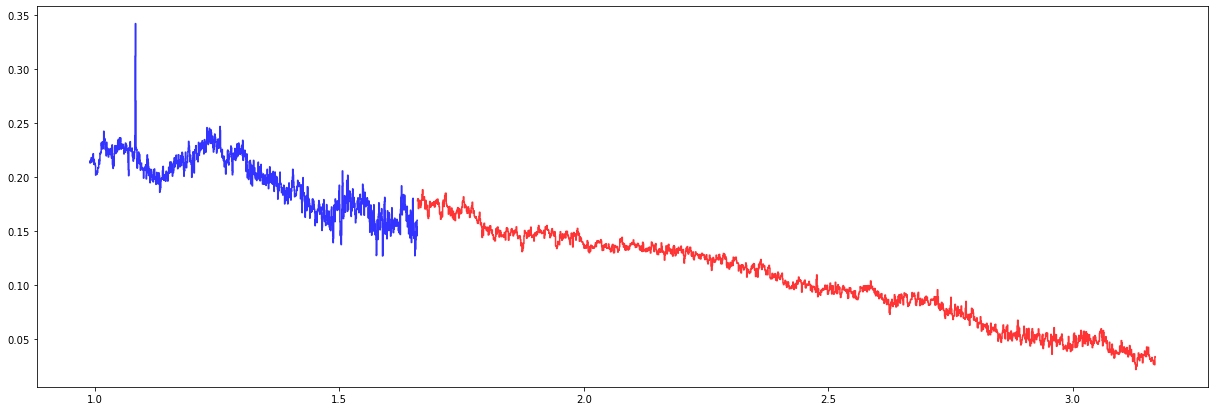

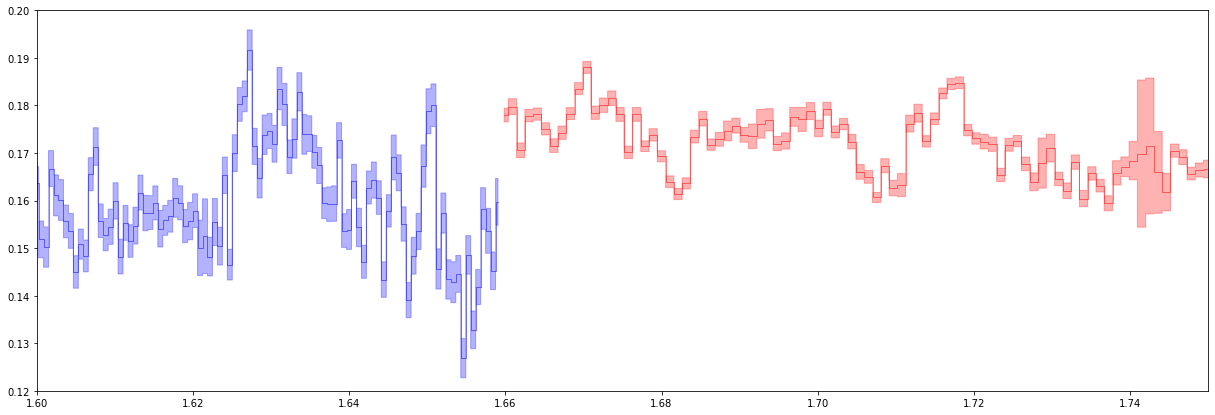

In [5]:
specset = dmd.prep.SpecSetfromList(data)

fig, ax = plt.subplots(figsize=(21, 7))
specset.plot(ax=ax, error_band=0, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=0.8)

fig, ax = plt.subplots(figsize=(21, 7))
specset.plot(ax=ax, error_band=0.3, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=1, linewidth=0.5)
ax.set_xlim(1.6, 1.75)
ax.set_ylim(0.12, 0.2)

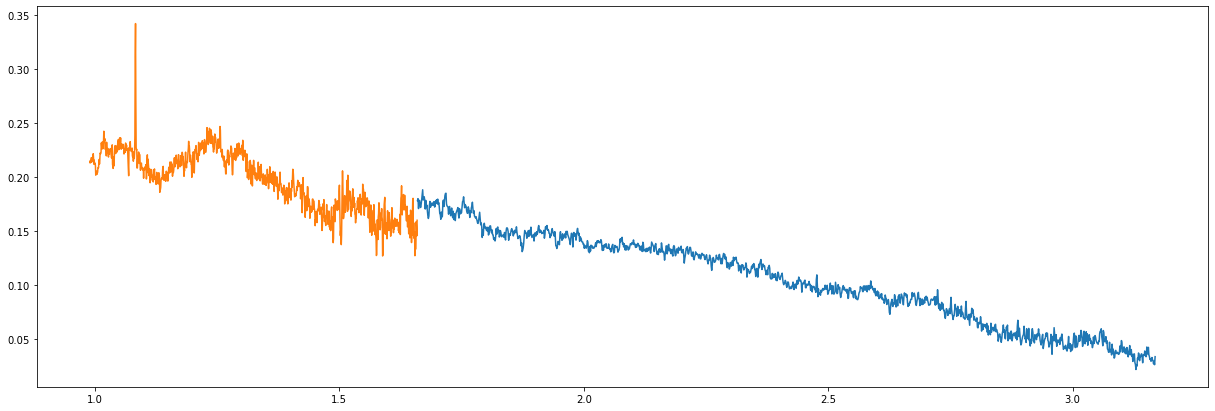

In [6]:
fig, ax = plt.subplots(figsize=(21, 7))
for spec in data:
    ax.plot(spec["lam"], spec["sky"])


In [7]:
for k in prev_configs.keys():
    print(k)
    for kk in prev_configs[k].keys():
        print("  ", kk)
    print()

run
   name
   filenames
   lambda_split
   lambda_min
   rawlimits_filename
   bestfits_filename
   pc_filename
   lineoutput_filename
   fluxlimits_filename
   paths

analysis
   width_factor
   padding
   num_knots
   chisq_step
   limit_guess
   max_clip_iters
   clipping_factor
   Ntrials
   Nbins
   power_threshold
   Nthreads
   inflate
   checkpoint

halo
   rho_s
   r_s
   sigma_v_kms
   r_sun
   z_sun
   v_sun
   ra_gc
   dec_gc
   sigma_v
   galcen
   pos_sun

system
   data_dir
   res_path
   AxionLimits_dir



In [8]:
keys_for_linesearch = {
    "analysis":[
      "width_factor", 
      "padding", 
      "num_knots", 
      "chisq_step", 
      "limit_guess", 
      "max_clip_iters", 
      "clipping_factor", 
      "Ntrials", 
      "Nbins", 
      "power_threshold"],
    "halo":[ 
      "sigma_v"]}
linesearch_configs = {k:prev_configs[k1][k] 
                       for k1, l1 in keys_for_linesearch.items()
                       for k in l1
                       if k in prev_configs[k1].keys()} 

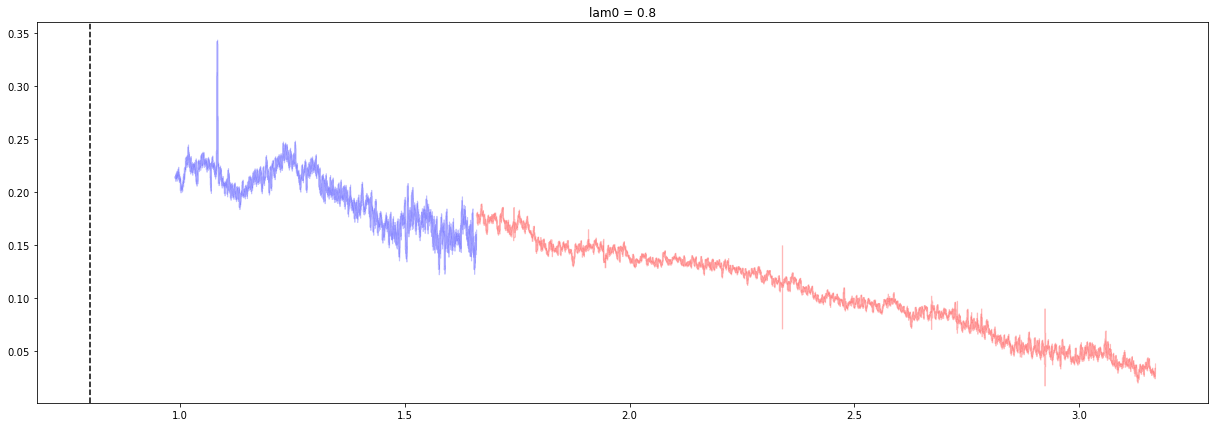

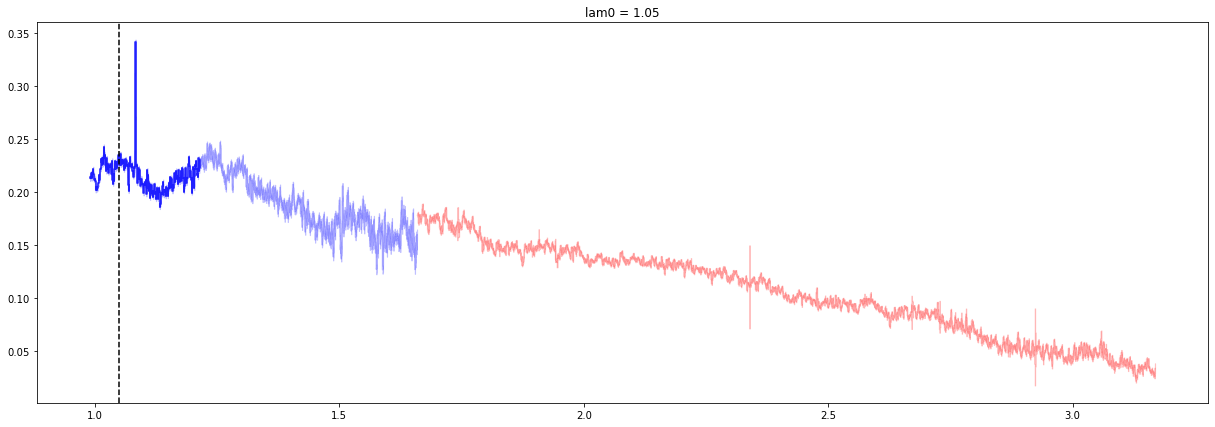

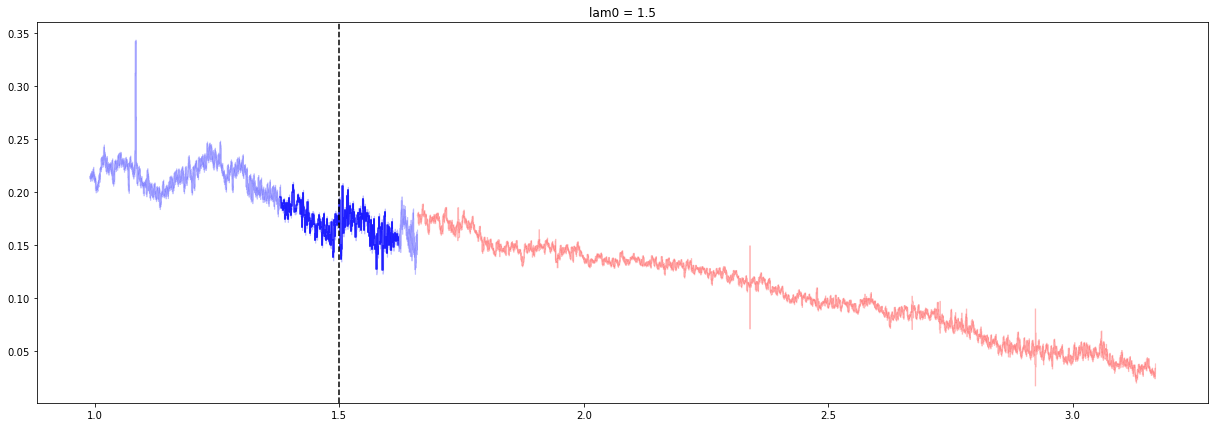

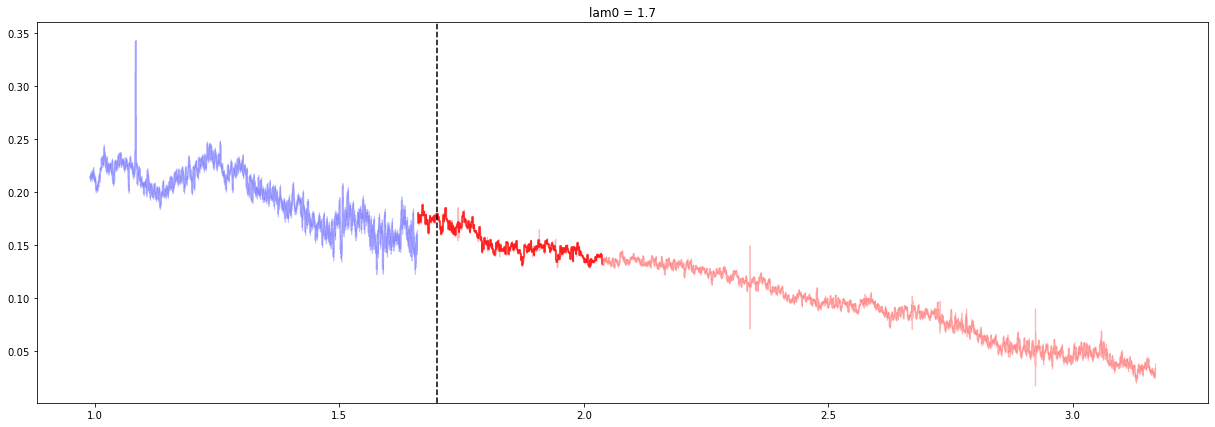

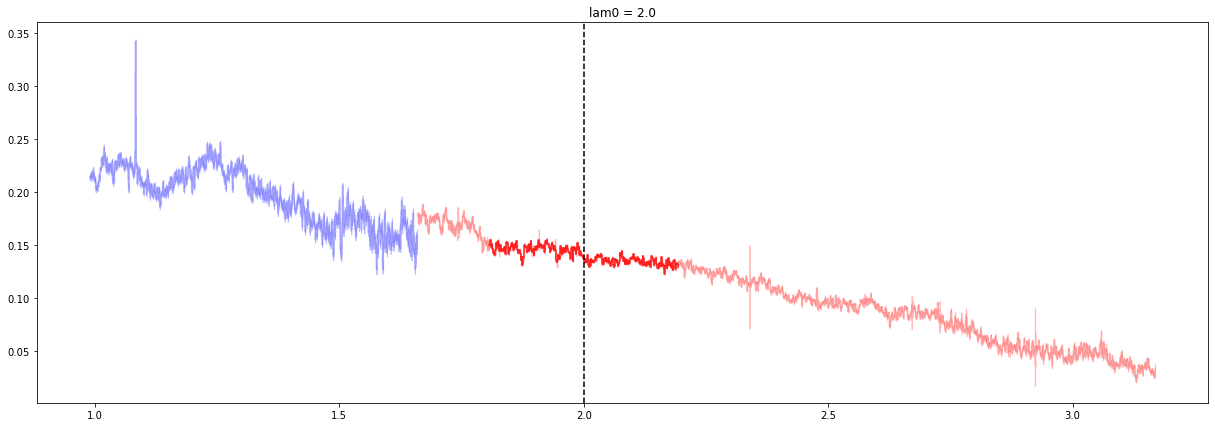

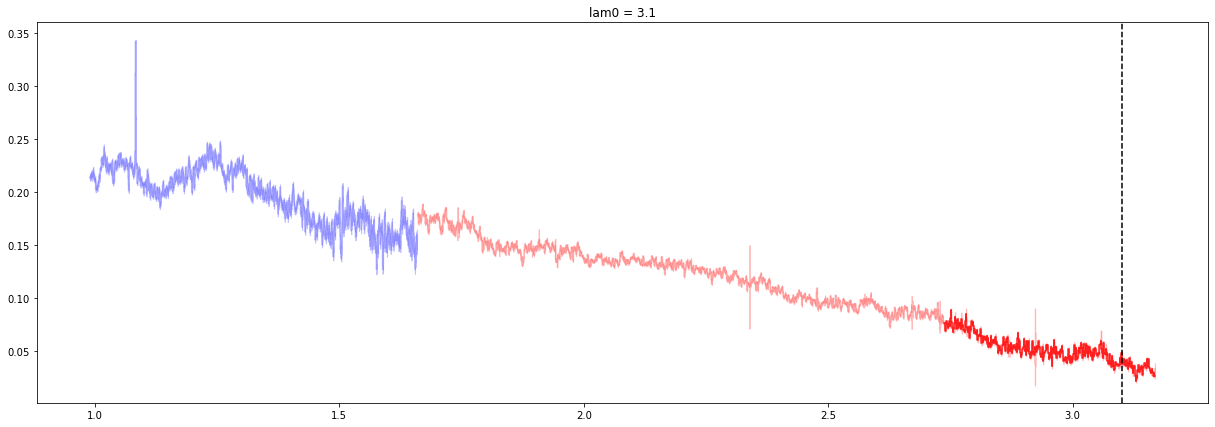

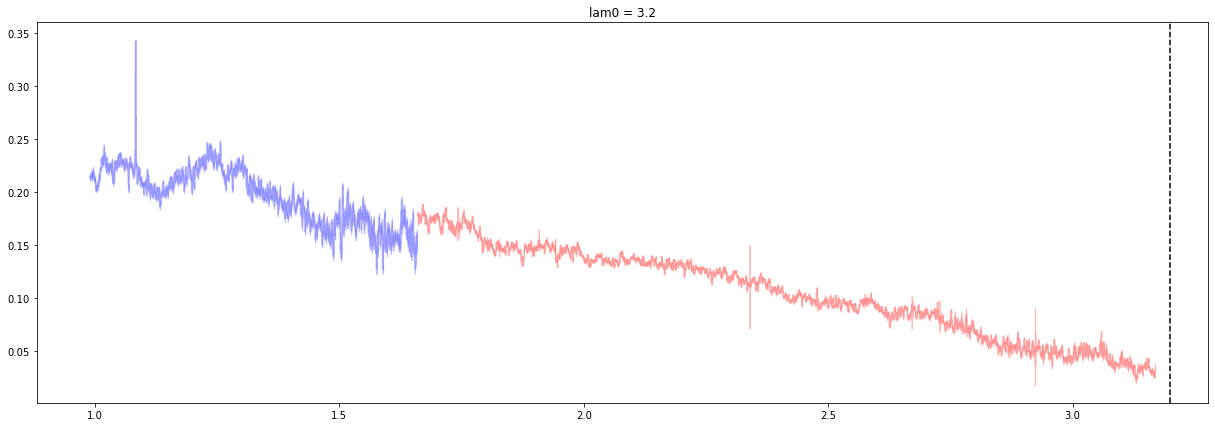

In [9]:
setup = dmd.linesearch.LineSearchSetup(**linesearch_configs)
for lam0 in [0.8, 1.05, 1.5, 1.7, 2.0, 3.1, 3.2]:
    fig, ax = plt.subplots(figsize=(21, 7))
    specset.plot(ax=ax, error_band=0.2, 
                distinct_plot_args=[{"color": "red"},
                                    {"color": "blue"}],
                alpha=0.2)
    search = dmd.linesearch.LineSearcher(setup, specset, lam0)
    specset.plot(ax=ax, error_band=0, mask=search.mask,
                distinct_plot_args=[{"color": "red"},
                                    {"color": "blue"}],
                alpha=0.8)
    ax.axvline(search.lam0, linestyle="--", color="black")
    ax.set_title(F"lam0 = {search.lam0}")

fitting continuum around lam0 = 0.8
best fit spine knots:
[]

fitting continuum around lam0 = 1.05
best fit spine knots:
[[0.20054398 0.22852014 0.21008206 0.20595378 0.22775982]]

fitting continuum around lam0 = 1.5
best fit spine knots:
[[0.19388543 0.17560627 0.16870354 0.16874599 0.14604815]]

fitting continuum around lam0 = 1.7
best fit spine knots:
[[0.17303796 0.16619941 0.1462182  0.14514535 0.13078088]]

fitting continuum around lam0 = 2.0
best fit spine knots:
[[0.144293   0.14617555 0.13977789 0.13486969 0.13122565]]

fitting continuum around lam0 = 3.1
best fit spine knots:
[[0.07844485 0.05823713 0.04861607 0.04340449 0.0280811 ]]

fitting continuum around lam0 = 3.2
best fit spine knots:
[]



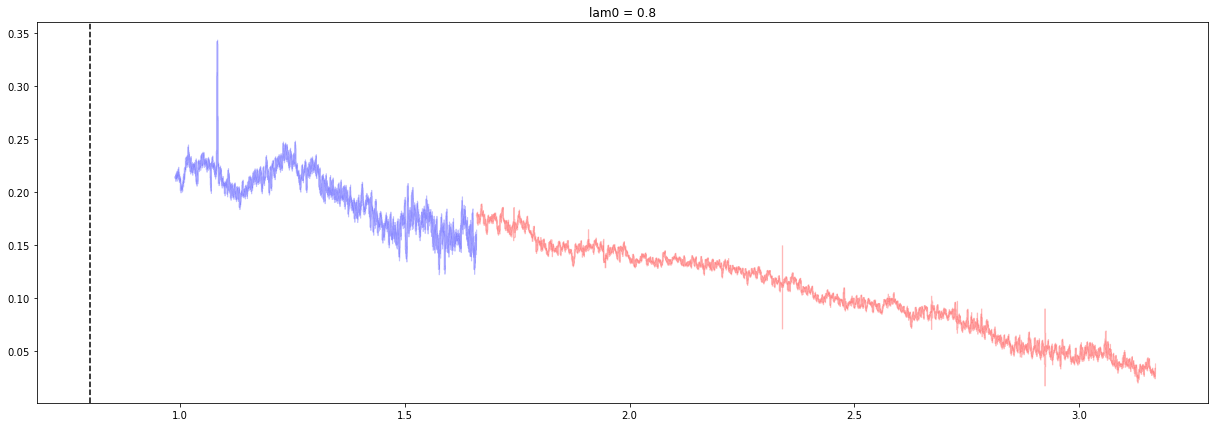

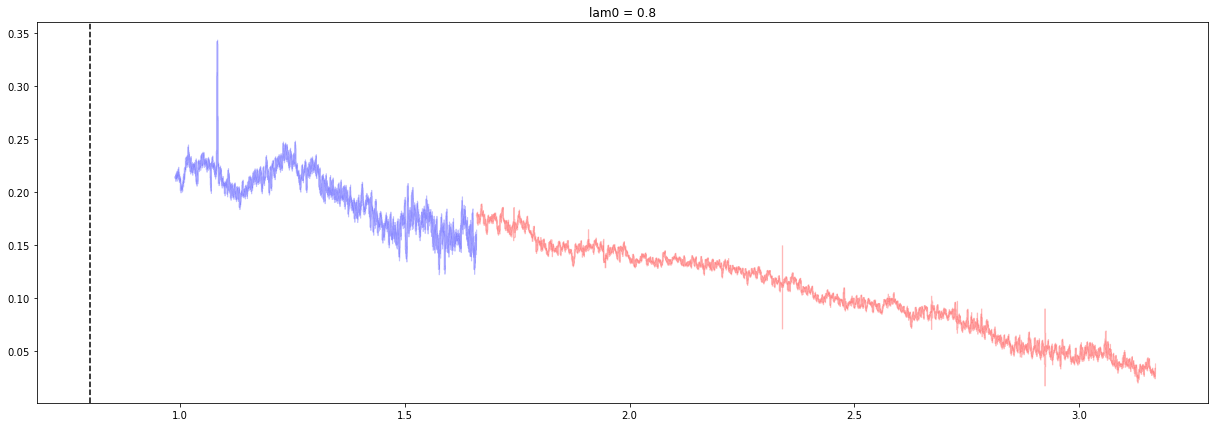

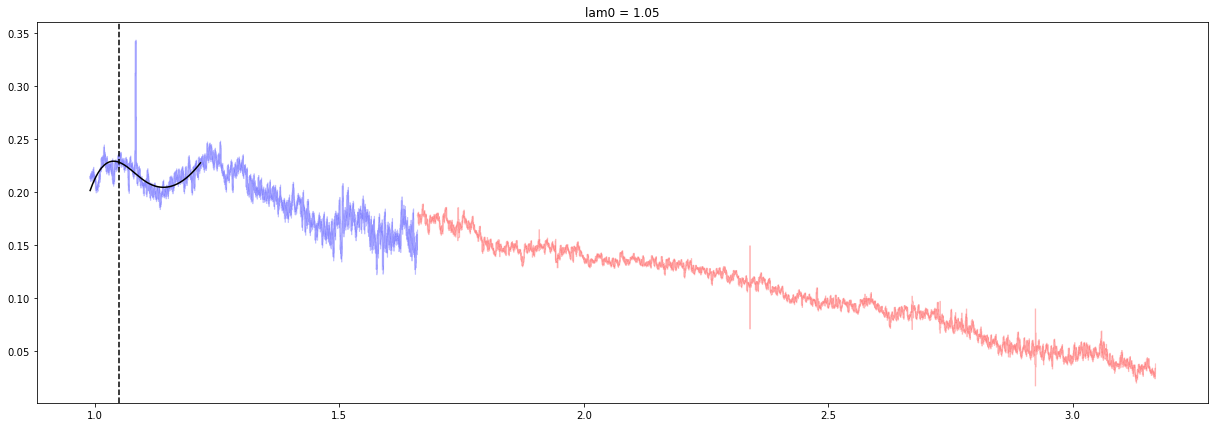

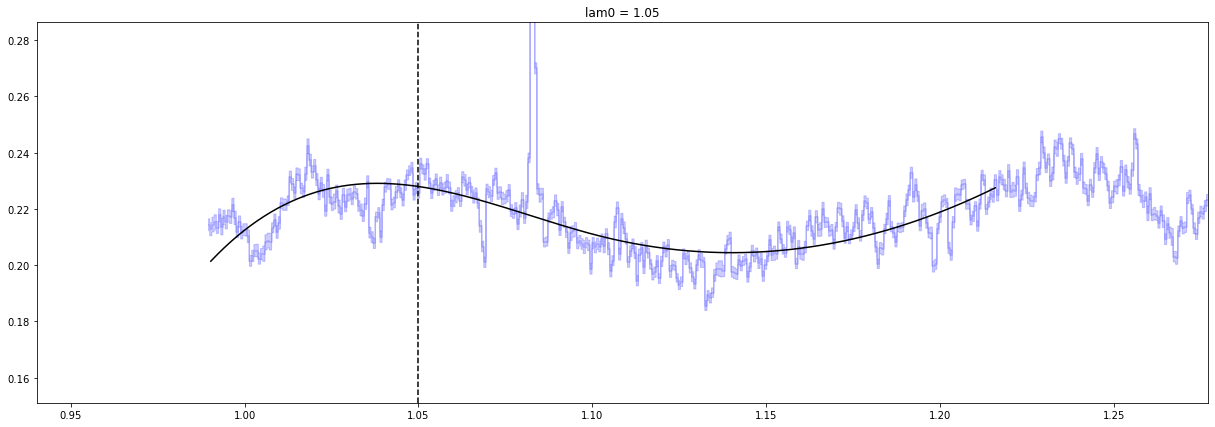

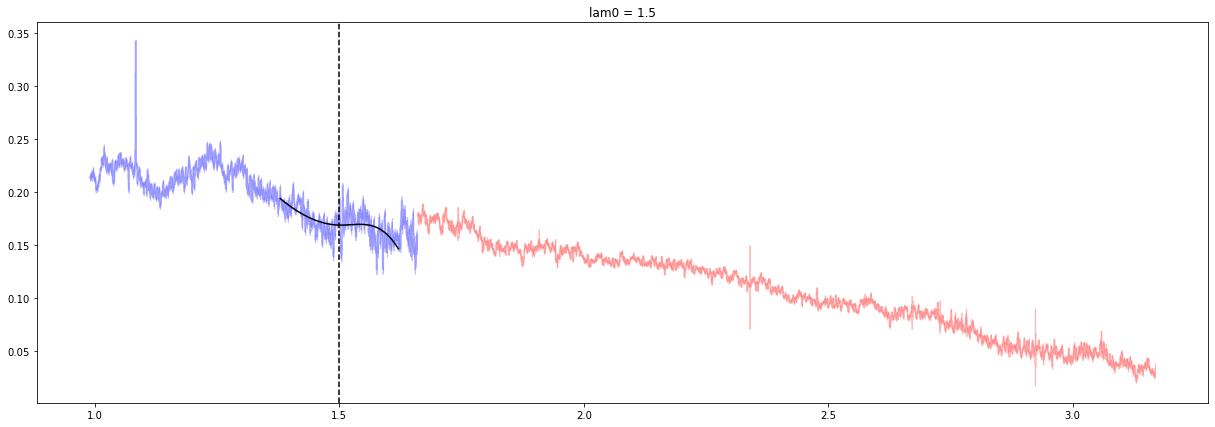

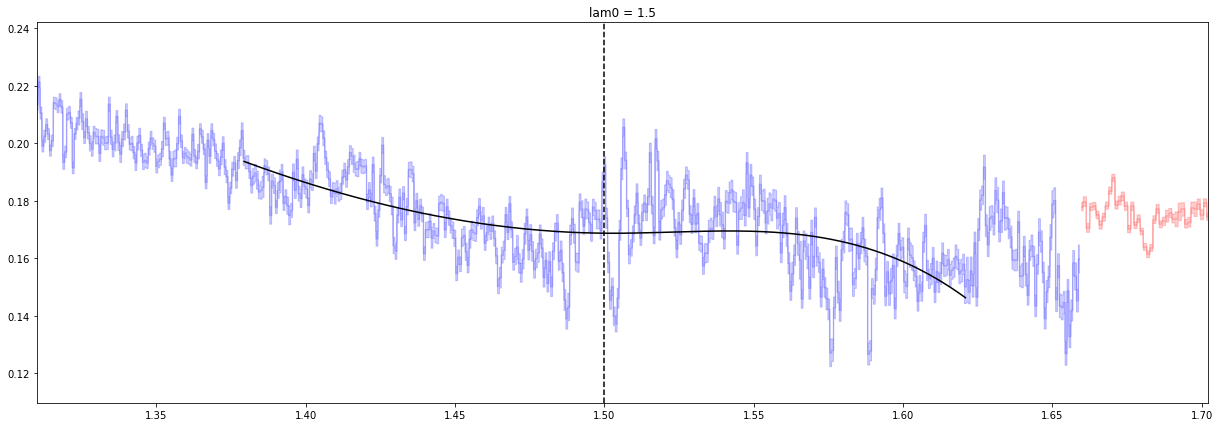

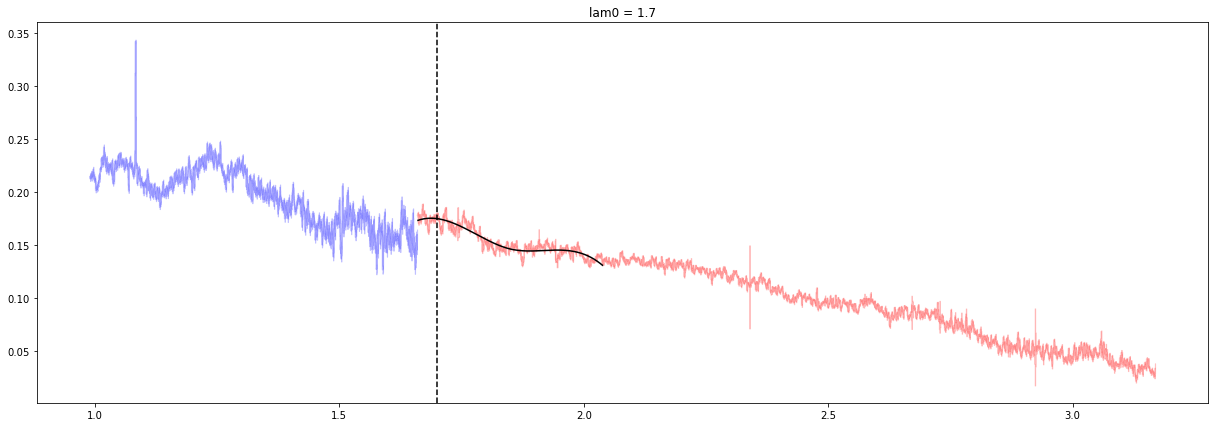

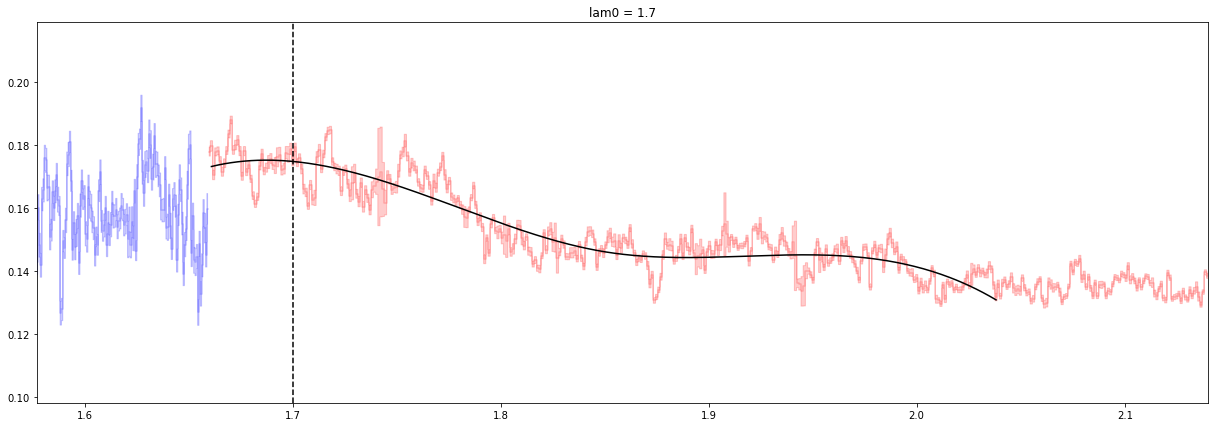

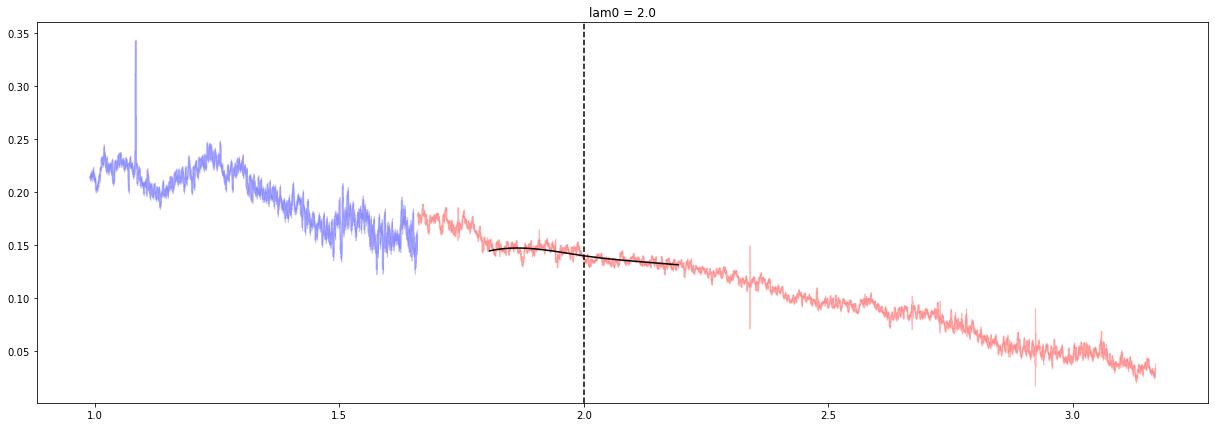

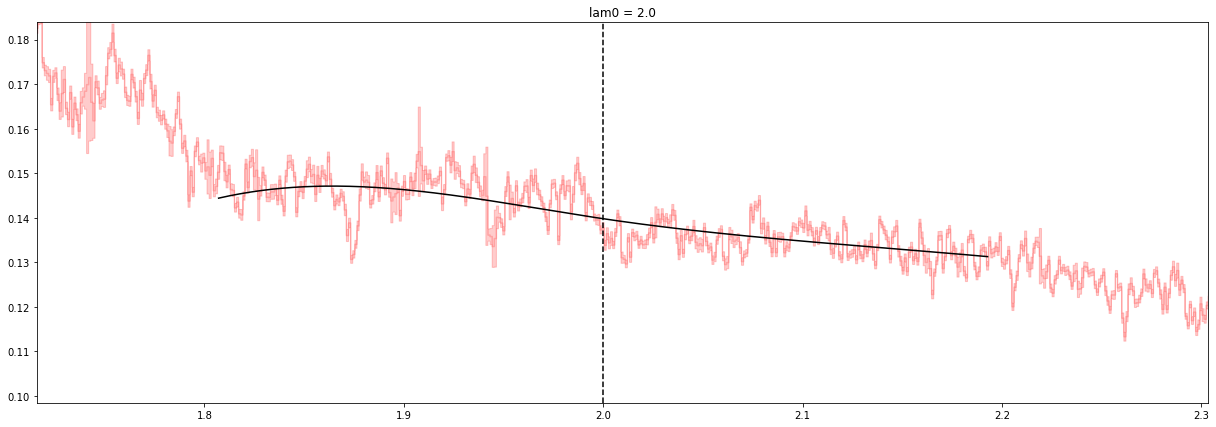

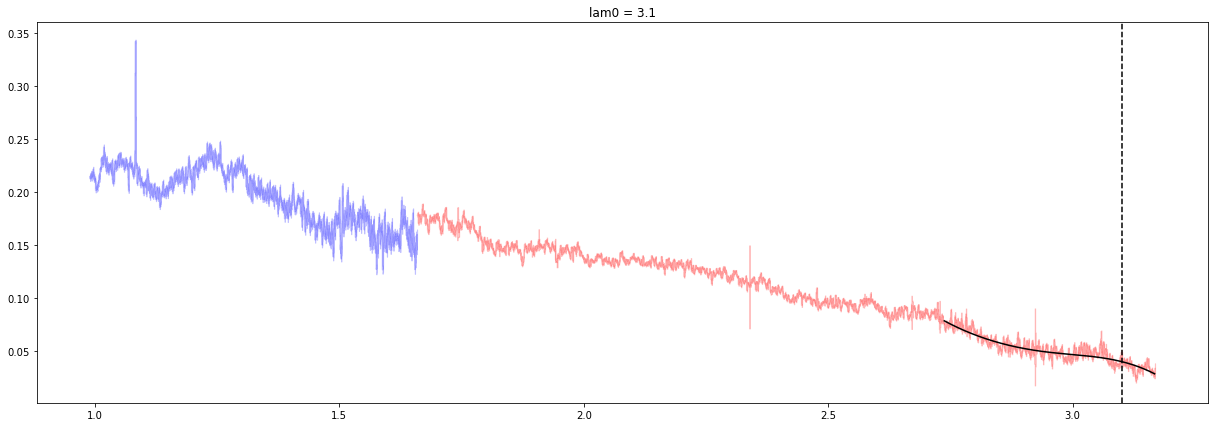

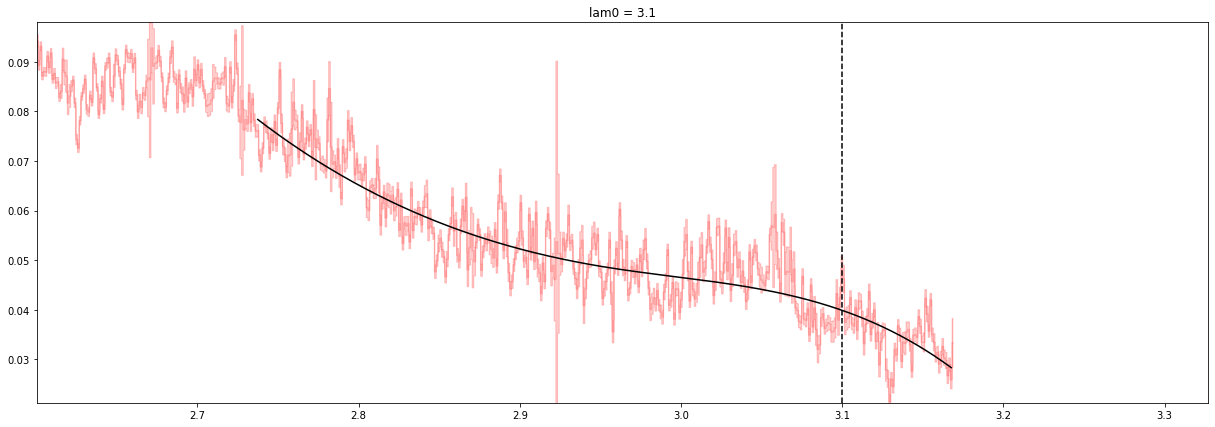

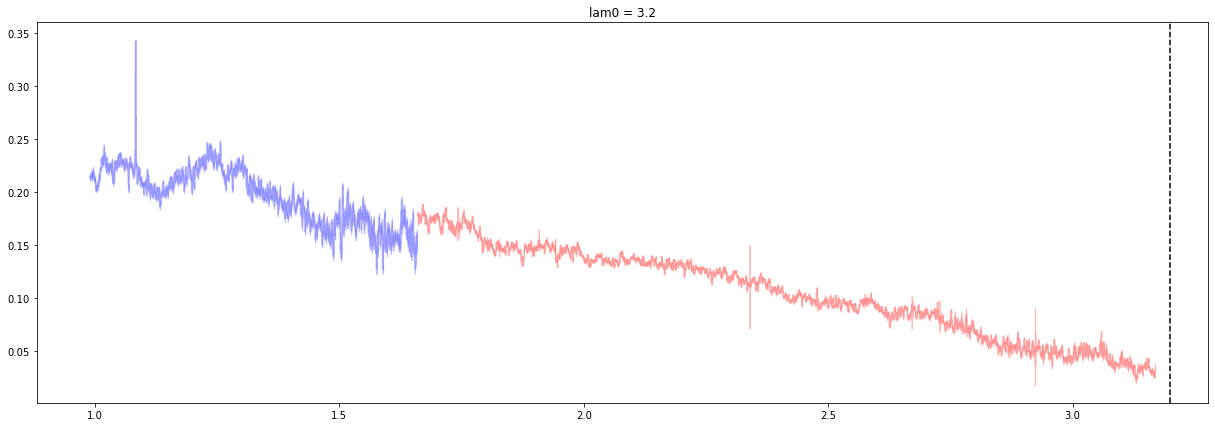

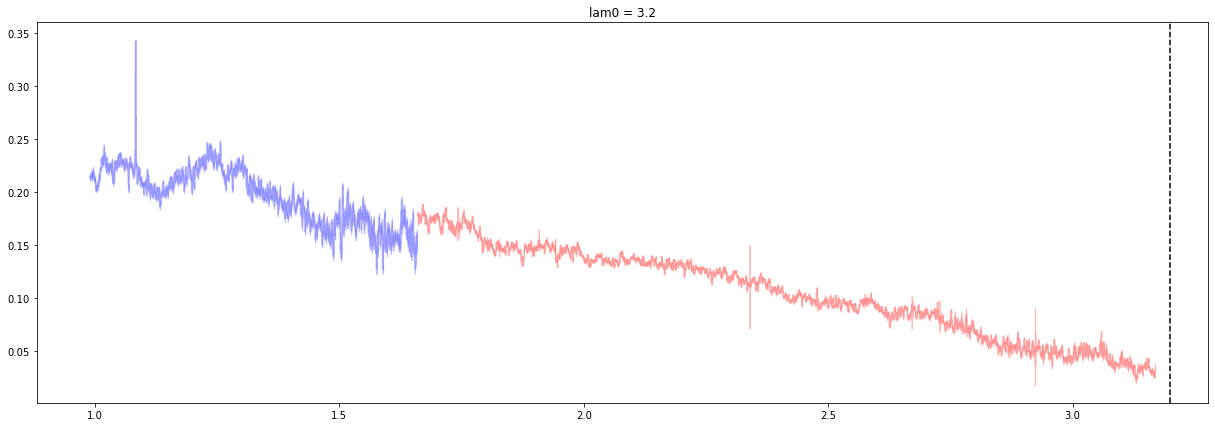

In [15]:
for lam0 in [0.8, 1.05, 1.5, 1.7, 2.0, 3.1, 3.2]:
    print(f"fitting continuum around lam0 = {lam0}")
    search = dmd.linesearch.LineSearcher(setup, specset, lam0)
    knot_vals = search.fit_continuum()
    print(f"best fit spine knots:\n{knot_vals}\n")

    margin = 0.05
    for plot_scale in ["full", "zoom"]:
        fig, ax = plt.subplots(figsize=(21, 7))
        specset.plot(ax=ax, error_band=0.2, 
                    distinct_plot_args=[{"color": "red"},
                                        {"color": "blue"}],
                    alpha=0.2)
        model = search.spline_plus_line_model(knot_vals, 0, search.lams_to_fit)
        for i_model, i_specs in enumerate(search.to_fit):
            ax.plot(search.lams_to_fit[i_specs], model[i_model], color="black")
        ax.axvline(search.lam0, linestyle="--", color="black")
        ax.set_title(F"lam0 = {search.lam0}")
        if plot_scale == "zoom" and len(model) > 0:
            left = search.fit_intervals[search.to_fit, 0].min()*(1 - margin)
            right = search.fit_intervals[search.to_fit, 1].max()*(1 + margin)
            top = max(max(m) for m in model)*(1 + 5*margin)
            bottom = min(min(m) for m in model)*(1 - 5*margin)
            ax.set_xlim(left, right)
            ax.set_ylim(bottom, top)

In [11]:
model

[]